# Data Generation using Modelling and Simulation for Machine Learning

## Traffic Queue Simulation using SimPy

This project generates synthetic data using a traffic queue simulation model and applies multiple machine learning models to predict average waiting time.

In [1]:
import sys
import os

# Allow notebook to access src folder
sys.path.append(os.path.abspath(".."))

from src.dataset_generator import generate_dataset
from src.train_models import train_and_evaluate

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = generate_dataset(1000)
df.head()

,arrival_rate,service_rate,counters,sim_time,avg_wait,max_queue
0,4.878445,12.123630,4,490,0.000071,2
1,9.953528,7.063169,2,236,0.172269,16
2,6.308764,3.465071,2,496,1.511619,43
3,5.270867,11.002973,5,304,0.000002,0
4,8.910890,2.754999,2,407,74.368495,1344


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   arrival_rate  1000 non-null   float64
 1   service_rate  1000 non-null   float64
 2   counters      1000 non-null   int64  
 3   sim_time      1000 non-null   int64  
 4   avg_wait      1000 non-null   float64
 5   max_queue     1000 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


,arrival_rate,service_rate,counters,sim_time,avg_wait,max_queue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.325062,8.615351,3.013000,296.974000,2.775165,43.313000
std,2.631780,3.727329,1.417335,115.603337,12.801991,193.578909
min,1.002905,2.004924,1.000000,100.000000,0.000000,0.000000
25%,3.022133,5.488081,2.000000,195.750000,0.000038,0.000000
50%,5.205783,8.702790,3.000000,294.500000,0.002227,2.000000
75%,7.610270,11.887417,4.000000,394.000000,0.041341,6.000000
max,9.989495,14.995848,5.000000,499.000000,123.350616,2011.000000


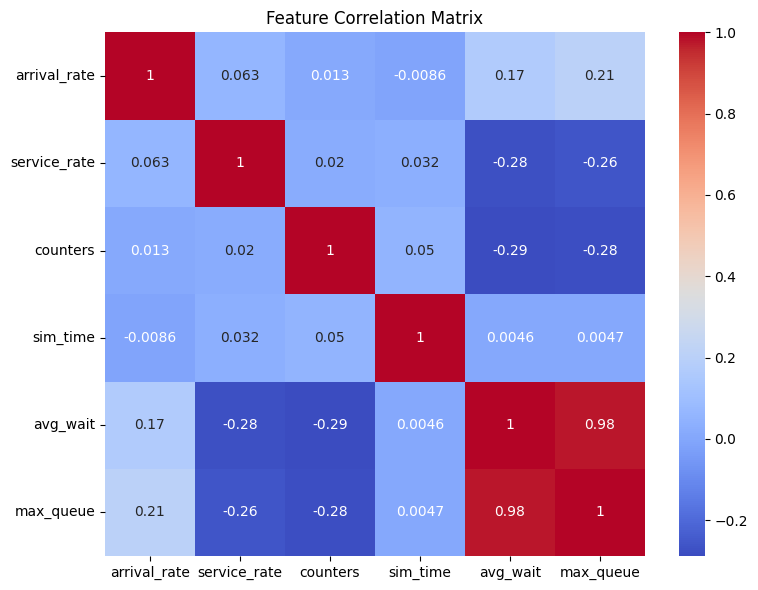

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../heatmap.png")
plt.show()

In [5]:
results = train_and_evaluate(df)
results

,Model,MAE,MSE,RMSE,R2
5,Gradient Boosting,0.228048,1.413565,1.188934,0.970959
4,Random Forest,0.262390,2.065736,1.437267,0.957560
3,Decision Tree,0.277340,2.254834,1.501611,0.953675
7,KNN,0.262895,2.470899,1.571910,0.949236
1,Ridge,0.846119,4.588921,2.142177,0.905722
0,Linear Regression,0.846208,4.588970,2.142188,0.905721
2,Lasso,0.541947,4.626191,2.150858,0.904956
6,SVR,0.601756,13.772995,3.711199,0.717038


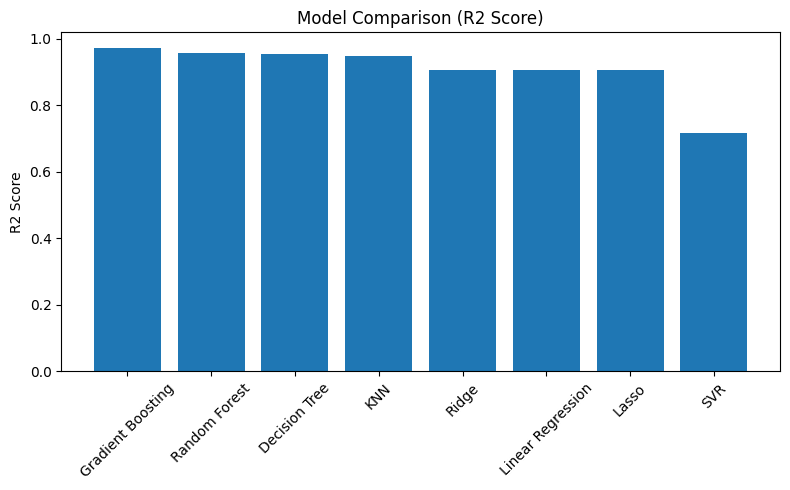

In [8]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2"])
plt.xticks(rotation=45)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.tight_layout()
plt.savefig("../model_comparison.png")
plt.show()

In [9]:
results.to_csv("../model_results.csv", index=False)

## Conclusion

Gradient Boosting achieved the highest R² score, indicating superior predictive performance for estimating average waiting time in the traffic simulation model.

Ensemble models outperformed linear and distance-based models, suggesting non-linear relationships within the simulated dataset.